In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/discucssion-poster/Myocardial_infarction.csv


In [ ]:
 !pip install lifelines

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 6.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.5/94.5 kB 5.6 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4031 sha256=70d1b8fb9c951908512ac7a39ee86289c616be513a1e5c519c492cc29f66efe4
  Stored in directory: /root/.cache/pip/wheels/25/cc/e0/ef2969164144c899fedb22b338f6703e2b9cf46eeebf254991
Successfully built autograd-gamma


In [ ]:
data = pd.read_csv('/kaggle/input/discucssion-poster/Myocardial_infarction.csv')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Sélectionner les colonnes pertinentes à l'admission (exclure treatment_columns)
columns_admission = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction à l'admission
X_admission = cluster_2_data[columns_admission]
y_admission = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled_admission, y_resampled_admission = smote.fit_resample(X_admission, y_admission)

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=30, random_state=seed)
X_resampled_pca_admission = pca.fit_transform(X_resampled_admission)

# Diviser les données en ensembles d'entraînement et de test
X_train_admission, X_test_admission, y_train_admission, y_test_admission = train_test_split(X_resampled_pca_admission, y_resampled_admission, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour SVM
param_grid_svm = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search_svm = GridSearchCV(SVC(random_state=seed), param_grid_svm, cv=3, n_jobs=-1, verbose=2)
grid_search_svm.fit(X_train_admission, y_train_admission)

# Meilleurs hyperparamètres trouvés pour SVM
best_params_svm = grid_search_svm.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour SVM
optimized_model_svm = SVC(random_state=seed, **best_params_svm)
optimized_model_svm.fit(X_train_admission, y_train_admission)

# Évaluer le modèle optimisé
y_pred_svm = optimized_model_svm.predict(X_test_admission)
accuracy_svm = accuracy_score(y_test_admission, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test_admission, y_pred_svm)
report_svm = classification_report(y_test_admission, y_pred_svm)

results_optimized_svm = {
    "best_params_svm": best_params_svm,
    "accuracy_svm": accuracy_svm,
    "conf_matrix_svm": conf_matrix_svm,
    "report_svm": report_svm
}

print("Best parameters for SVM Admission:")
print(best_params_svm)

print("Accuracy of SVM model Admission:")
print(accuracy_svm)

print("Confusion Matrix for SVM modelAdmission:")
print(conf_matrix_svm)

print("Classification Report for SVM model Admission:")
print(report_svm)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for SVM Admission:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy of SVM model Admission:
0.9542961608775137
Confusion Matrix for SVM modelAdmission:
[[259  11]
 [ 14 263]]
Classification Report for SVM model Admission:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       270
           1       0.96      0.95      0.95       277

    accuracy                           0.95       547
   macro avg       0.95      0.95      0.95       547
weighted avg       0.95      0.95      0.95       547



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Ajouter les informations sur les médicaments aux données du cluster 2
treatment_columns = ['NA_KB', 'NOT_NA_KB', 'LID_KB', 'NITR_S', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n',
                     'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n',
                     'GEPAR_S_n', 'ASP_S_n', 'TIKL_S_n', 'TRENT_S_n']

for col in treatment_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Sélectionner les colonnes pertinentes pour les 72 heures
columns_72h_with_treatment = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction après 72 heures
X_72h_with_treatment = cluster_2_data[columns_72h_with_treatment]
y_72h = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled, y_resampled = smote.fit_resample(X_72h_with_treatment, y_72h)

# Réduction de dimensionnalité avec PCA à 70 composants
pca_72h = PCA(n_components=70, random_state=seed)
X_resampled_72h_pca = pca_72h.fit_transform(X_resampled)

# Diviser les données en ensembles d'entraînement et de test
X_train_72h, X_test_72h, y_train_72h, y_test_72h = train_test_split(X_resampled_72h_pca, y_resampled, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour SVM après 72 heures
param_grid_svm_72h = {
    'C': [0.1, 1, 10, 100],
    'gamma': [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf', 'poly', 'sigmoid']
}

grid_search_svm_72h = GridSearchCV(SVC(random_state=seed), param_grid_svm_72h, cv=3, n_jobs=-1, verbose=2)
grid_search_svm_72h.fit(X_train_72h, y_train_72h)

# Meilleurs hyperparamètres trouvés pour SVM après 72 heures
best_params_svm_72h = grid_search_svm_72h.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour SVM
optimized_model_svm_72h = SVC(random_state=seed, **best_params_svm_72h)
optimized_model_svm_72h.fit(X_train_72h, y_train_72h)

# Évaluer le modèle optimisé
y_pred_svm_72h = optimized_model_svm_72h.predict(X_test_72h)
accuracy_svm_72h = accuracy_score(y_test_72h, y_pred_svm_72h)
conf_matrix_svm_72h = confusion_matrix(y_test_72h, y_pred_svm_72h)
report_svm_72h = classification_report(y_test_72h, y_pred_svm_72h)

results_optimized_svm_72h = {
    "best_params_svm_72h": best_params_svm_72h,
    "accuracy_svm_72h": accuracy_svm_72h,
    "conf_matrix_svm_72h": conf_matrix_svm_72h,
    "report_svm_72h": report_svm_72h
}

print("Best parameters for SVM after 72 hours:")
print(best_params_svm_72h)

print("Accuracy of SVM model after 72 hours:")
print(accuracy_svm_72h)

print("Confusion Matrix for SVM model after 72 hours:")
print(conf_matrix_svm_72h)

print("Classification Report for SVM model after 72 hours:")
print(report_svm_72h)


Fitting 3 folds for each of 48 candidates, totalling 144 fits
Best parameters for SVM after 72 hours:
{'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Accuracy of SVM model after 72 hours:
0.946983546617916
Confusion Matrix for SVM model after 72 hours:
[[263   7]
 [ 22 255]]
Classification Report for SVM model after 72 hours:
              precision    recall  f1-score   support

           0       0.92      0.97      0.95       270
           1       0.97      0.92      0.95       277

    accuracy                           0.95       547
   macro avg       0.95      0.95      0.95       547
weighted avg       0.95      0.95      0.95       547

[CV] END ........................C=0.1, gamma=1, kernel=poly; total time=   0.1s
[CV] END .....................C=0.1, gamma=1, kernel=sigmoid; total time=   0.2s
[CV] END ......................C=0.1, gamma=0.1, kernel=poly; total time=   0.1s
[CV] END ...................C=0.1, gamma=0.1, kernel=sigmoid; total time=   0.2s
[CV] END ...................

In [ ]:
# RandomForestClassifier

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Sélectionner les colonnes pertinentes à l'admission (exclure treatment_columns)
columns_admission = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction à l'admission
X_admission = cluster_2_data[columns_admission]
y_admission = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled_admission, y_resampled_admission = smote.fit_resample(X_admission, y_admission)

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=30, random_state=seed)
X_resampled_pca_admission = pca.fit_transform(X_resampled_admission)

# Diviser les données en ensembles d'entraînement et de test
X_train_admission, X_test_admission, y_train_admission, y_test_admission = train_test_split(X_resampled_pca_admission, y_resampled_admission, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=seed), param_grid_rf, cv=3, n_jobs=-1, verbose=2)
grid_search_rf.fit(X_train_admission, y_train_admission)

# Meilleurs hyperparamètres trouvés pour Random Forest
best_params_rf = grid_search_rf.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour Random Forest
optimized_model_rf = RandomForestClassifier(random_state=seed, **best_params_rf)
optimized_model_rf.fit(X_train_admission, y_train_admission)

# Évaluer le modèle optimisé
y_pred_rf = optimized_model_rf.predict(X_test_admission)
accuracy_rf = accuracy_score(y_test_admission, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test_admission, y_pred_rf)
report_rf = classification_report(y_test_admission, y_pred_rf)

results_optimized_rf = {
    "best_params_rf": best_params_rf,
    "accuracy_rf": accuracy_rf,
    "conf_matrix_rf": conf_matrix_rf,
    "report_rf": report_rf
}

print("Best parameters for Random Forest Admission:")
print(best_params_rf)

print("Accuracy of Random Forest model Admission:")
print(accuracy_rf)

print("Confusion Matrix for Random Forest model Admission:")
print(conf_matrix_rf)

print("Classification Report for Random Forest model Admission:")
print(report_rf)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END .....................C=10, gamma=0.001, kernel=poly; total time=   0.1s
[CV] END ..................C=10, gamma=0.001, kernel=sigmoid; total time=   0.1s
[CV] END ........................C=100, gamma=1, kernel=poly; total time=   0.1s
[CV] END ........................C=100, gamma=1, kernel=poly; total time=   0.1s
[CV] END ......................C=100, gamma=0.1, kernel=poly; total time=   0.1s
[CV] END ......................C=100, gamma=0.1, kernel=poly; total time=   0.1s
[CV] END ......................C=100, gamma=0.01, kernel=rbf; total time=   0.2s
[CV] END .....................C=100, gamma=0.01, kernel=poly; total time=   0.1s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .....................C=100, gamma=0.001, kernel=rbf; total time=   0.1s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.2s
[CV] END ........................C=0.1, gamma=

In [ ]:
print("Best parameters for Random Forest:")
print(best_params_rf)

print("Accuracy of Random Forest model:")
print(accuracy_rf)

print("Confusion Matrix for Random Forest model:")
print(conf_matrix_rf)

print("Classification Report for Random Forest model:")
print(report_rf)


Best parameters for Random Forest:
{'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Accuracy of Random Forest model:
0.870201096892139
Confusion Matrix for Random Forest model:
[[228  42]
 [ 29 248]]
Classification Report for Random Forest model:
              precision    recall  f1-score   support

           0       0.89      0.84      0.87       270
           1       0.86      0.90      0.87       277

    accuracy                           0.87       547
   macro avg       0.87      0.87      0.87       547
weighted avg       0.87      0.87      0.87       547



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Ajouter les informations sur les médicaments aux données du cluster 2
treatment_columns = ['NA_KB', 'NOT_NA_KB', 'LID_KB', 'NITR_S', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n',
                     'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n',
                     'GEPAR_S_n', 'ASP_S_n', 'TIKL_S_n', 'TRENT_S_n']

for col in treatment_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Sélectionner les colonnes pertinentes pour les 72 heures
columns_72h_with_treatment = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction après 72 heures
X_72h_with_treatment = cluster_2_data[columns_72h_with_treatment]
y_72h = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled, y_resampled = smote.fit_resample(X_72h_with_treatment, y_72h)

# Réduction de dimensionnalité avec PCA à 70 composants
pca_72h = PCA(n_components=70, random_state=seed)
X_resampled_72h_pca = pca_72h.fit_transform(X_resampled)

# Diviser les données en ensembles d'entraînement et de test
X_train_72h, X_test_72h, y_train_72h, y_test_72h = train_test_split(X_resampled_72h_pca, y_resampled, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour Random Forest après 72 heures
param_grid_rf_72h = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search_rf_72h = GridSearchCV(RandomForestClassifier(random_state=seed), param_grid_rf_72h, cv=3, n_jobs=-1, verbose=2)
grid_search_rf_72h.fit(X_train_72h, y_train_72h)

# Meilleurs hyperparamètres trouvés pour Random Forest après 72 heures
best_params_rf_72h = grid_search_rf_72h.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour Random Forest
optimized_model_rf_72h = RandomForestClassifier(random_state=seed, **best_params_rf_72h)
optimized_model_rf_72h.fit(X_train_72h, y_train_72h)

# Évaluer le modèle optimisé
y_pred_rf_72h = optimized_model_rf_72h.predict(X_test_72h)
accuracy_rf_72h = accuracy_score(y_test_72h, y_pred_rf_72h)
conf_matrix_rf_72h = confusion_matrix(y_test_72h, y_pred_rf_72h)
report_rf_72h = classification_report(y_test_72h, y_pred_rf_72h)

results_optimized_rf_72h = {
    "best_params_rf_72h": best_params_rf_72h,
    "accuracy_rf_72h": accuracy_rf_72h,
    "conf_matrix_rf_72h": conf_matrix_rf_72h,
    "report_rf_72h": report_rf_72h
}

print("Best parameters for Random Forest after 72 hours:")
print(best_params_rf_72h)

print("Accuracy of Random Forest model after 72 hours:")
print(accuracy_rf_72h)

print("Confusion Matrix for Random Forest model after 72 hours:")
print(conf_matrix_rf_72h)

print("Classification Report for Random Forest model after 72 hours:")
print(report_rf_72h)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.4s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=50; total time=   0.3s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.7s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.4s
[CV] END max_depth=20, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.3s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total time=   0.7s
[CV] END max_depth=20, min_samples_leaf=2, min_samples_split=2, n_estimators=200; total time=   1.3s
[CV] END max_depth=20, min_sam

In [ ]:
print("Best parameters for Random Forest after 72 hours:")
print(best_params_rf_72h)

print("Accuracy of Random Forest model after 72 hours:")
print(accuracy_rf_72h)

print("Confusion Matrix for Random Forest model after 72 hours:")
print(conf_matrix_rf_72h)

print("Classification Report for Random Forest model after 72 hours:")
print(report_rf_72h)


# GradientBoostingClassifier

[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=2, n_estimators=200; total time=   2.0s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=100; total time=   0.8s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=5, n_estimators=200; total time=   1.7s
[CV] END max_depth=20, min_samples_leaf=4, min_samples_split=10, n_estimators=200; total time=   1.7s
[CV] END max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=100; total time=   1.0s
[CV] END max_depth=30, min_samples_leaf=1, min_samples_split=2, n_estimators=200; total time=   1.9s
[CV] END max_depth=30, min_samples_leaf=1, min_samples_split=5, n_estimators=100; total time=   0.9s
[CV] END max_depth=30, min_samples_leaf=1, min_samples_split=5, n_estimators=200; total time=   1.9s
[CV] END max_depth=30, min_samples_leaf=1, min_samples_split=10, n_estimators=200; total time=   1.9s
[CV] END max_depth=30, min_samples_leaf=2, min_samples_split=2, n_estimators=100; total t

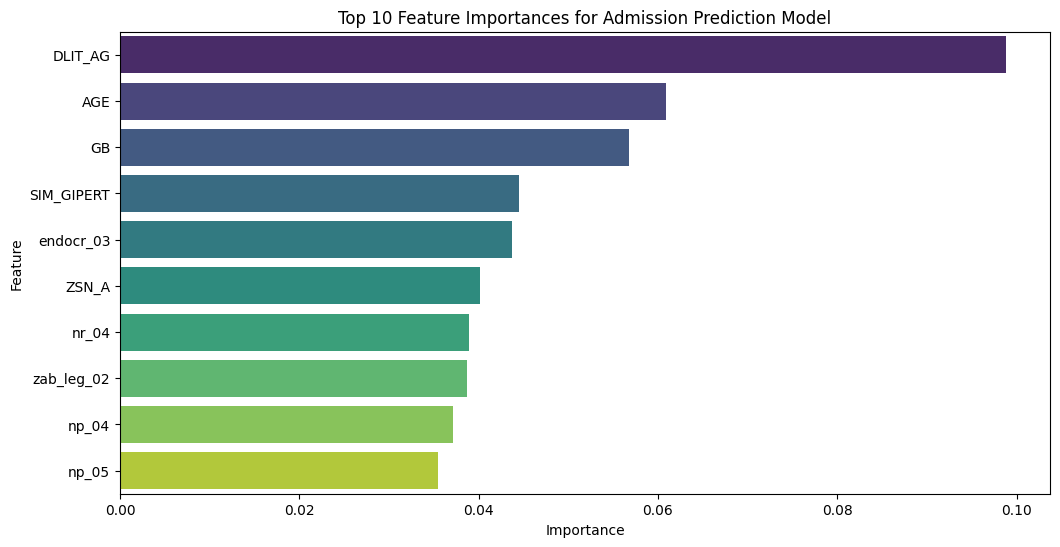

{'best_params_admission': {'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}, 'accuracy_admission': 0.8482632541133455, 'conf_matrix_admission': array([[218,  52],
       [ 31, 246]]), 'report_admission': '              precision    recall  f1-score   support\n\n           0       0.88      0.81      0.84       270\n           1       0.83      0.89      0.86       277\n\n    accuracy                           0.85       547\n   macro avg       0.85      0.85      0.85       547\nweighted avg       0.85      0.85      0.85       547\n'}


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Sélectionner les colonnes pertinentes à l'admission (exclure treatment_columns)
columns_admission = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction à l'admission
X_admission = cluster_2_data[columns_admission]
y_admission = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled_admission, y_resampled_admission = smote.fit_resample(X_admission, y_admission)

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=30, random_state=seed)
X_resampled_pca_admission = pca.fit_transform(X_resampled_admission)

# Diviser les données en ensembles d'entraînement et de test
X_train_admission, X_test_admission, y_train_admission, y_test_admission = train_test_split(X_resampled_pca_admission, y_resampled_admission, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour Gradient Boosting
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=seed), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_admission, y_train_admission)

# Meilleurs hyperparamètres trouvés pour Gradient Boosting
best_params_admission = grid_search.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour Gradient Boosting
optimized_model_admission = GradientBoostingClassifier(random_state=seed, **best_params_admission)
optimized_model_admission.fit(X_train_admission, y_train_admission)

# Évaluer le modèle optimisé
y_pred_admission = optimized_model_admission.predict(X_test_admission)
accuracy_admission = accuracy_score(y_test_admission, y_pred_admission)
conf_matrix_admission = confusion_matrix(y_test_admission, y_pred_admission)
report_admission = classification_report(y_test_admission, y_pred_admission)

# Importance des fonctionnalités
feature_importances_admission = optimized_model_admission.feature_importances_
features_admission = columns_admission[:30]  # Car PCA réduit à 30 composants

# Créer un DataFrame pour les importances
importance_df_admission = pd.DataFrame({'Feature': features_admission, 'Importance': feature_importances_admission})

# Trier les importances par ordre décroissant
importance_df_admission = importance_df_admission.sort_values(by='Importance', ascending=False)

# Afficher les 10 caractéristiques les plus importantes
top_10_features_admission = importance_df_admission.head(10)

# Afficher les résultats
print("Top 10 features by importance at admission:")
print(top_10_features_admission)

# Graphique des importances des fonctionnalités
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features_admission, palette='viridis')
plt.title('Top 10 Feature Importances for Admission Prediction Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

results_optimized_admission = {
    "best_params_admission": best_params_admission,
    "accuracy_admission": accuracy_admission,
    "conf_matrix_admission": conf_matrix_admission,
    "report_admission": report_admission
}

print(results_optimized_admission)


In [ ]:
print("Best parameters Gradient Boosting Admmision:")
print(best_params_admission)

print("Accuracy of Gradient Boosting Admmision:")
print(accuracy_admission)

print("Confusion Matrix for Gradient Boosting Admmision:")
print(conf_matrix_admission)

print("Classification Report for Gradient Boosting Admmision:")
print(report_admission)

Best parameters Gradient Boosting Admmision:
{'learning_rate': 0.1, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy of Gradient Boosting Admmision:
0.8482632541133455
Confusion Matrix for Gradient Boosting Admmision:
[[218  52]
 [ 31 246]]
Classification Report for Gradient Boosting Admmision:
              precision    recall  f1-score   support

           0       0.88      0.81      0.84       270
           1       0.83      0.89      0.86       277

    accuracy                           0.85       547
   macro avg       0.85      0.85      0.85       547
weighted avg       0.85      0.85      0.85       547



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Fixer la graine aléatoire
seed = 42
np.random.seed(seed)
import random
random.seed(seed)

# Charger les données
# data = pd.read_csv('votre_fichier.csv')  # Assurez-vous de charger vos données ici

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=seed)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']

# Ajouter les informations sur les médicaments aux données du cluster 2
treatment_columns = ['NA_KB', 'NOT_NA_KB', 'LID_KB', 'NITR_S', 'NA_R_1_n', 'NA_R_2_n', 'NA_R_3_n',
                     'NOT_NA_1_n', 'NOT_NA_2_n', 'NOT_NA_3_n', 'LID_S_n', 'B_BLOK_S_n', 'ANT_CA_S_n',
                     'GEPAR_S_n', 'ASP_S_n', 'TIKL_S_n', 'TRENT_S_n']

for col in treatment_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Sélectionner les colonnes pertinentes pour les 72 heures
columns_72h_with_treatment = [col for col in cluster_2_data.columns if col not in ['Cluster', 'ZSN']]

# Préparer les données pour la prédiction après 72 heures
X_72h_with_treatment = cluster_2_data[columns_72h_with_treatment]
y_72h = cluster_2_data['ZSN']

# Rééchantillonner les données pour équilibrer les classes
smote = SMOTE(random_state=seed)
X_resampled, y_resampled = smote.fit_resample(X_72h_with_treatment, y_72h)

# Réduction de dimensionnalité avec PCA
pca = PCA(n_components=90, random_state=seed)
X_resampled_pca = pca.fit_transform(X_resampled)

# Diviser les données en ensembles d'entraînement et de test
X_train_72h, X_test_72h, y_train_72h, y_test_72h = train_test_split(X_resampled_pca, y_resampled, test_size=0.3, random_state=seed)

# Utiliser GridSearchCV pour trouver les meilleurs hyperparamètres pour Gradient Boosting
param_grid = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(estimator=GradientBoostingClassifier(random_state=seed), param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
grid_search.fit(X_train_72h, y_train_72h)

# Meilleurs hyperparamètres trouvés pour Gradient Boosting
best_params_72h = grid_search.best_params_

# Former le modèle optimisé avec les meilleurs hyperparamètres pour Gradient Boosting
optimized_model_72h = GradientBoostingClassifier(random_state=seed, **best_params_72h)
optimized_model_72h.fit(X_train_72h, y_train_72h)

# Évaluer le modèle optimisé
y_pred_72h = optimized_model_72h.predict(X_test_72h)
accuracy_72h = accuracy_score(y_test_72h, y_pred_72h)
conf_matrix_72h = confusion_matrix(y_test_72h, y_pred_72h)
report_72h = classification_report(y_test_72h, y_pred_72h)

# Importance des fonctionnalités
feature_importances_72h = optimized_model_72h.feature_importances_
features_72h = columns_72h_with_treatment[:90]  # Car PCA réduit à 90 composants

# Créer un DataFrame pour les importances
importance_df_72h = pd.DataFrame({'Feature': features_72h, 'Importance': feature_importances_72h})

# Trier les importances par ordre décroissant
importance_df_72h = importance_df_72h.sort_values(by='Importance', ascending=False)

# Afficher les 10 caractéristiques les plus importantes
top_10_features_72h = importance_df_72h.head(10)

# Afficher les résultats
print("Top 10 features by importance after 72 hours:")
print(top_10_features_72h)

# Graphique des importances des fonctionnalités
plt.figure(figsize=(12, 6))
sns.barplot(x='Importance', y='Feature', data=top_10_features_72h, palette='viridis')
plt.title('Top 10 Feature Importances for 72h Prediction Model')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

results_optimized_72h = {
    "best_params_72h": best_params_72h,
    "accuracy_72h": accuracy_72h,
    "conf_matrix_72h": conf_matrix_72h,
    "report_72h": report_72h
}

print(results_optimized_72h)


In [ ]:
print("Best parameters for Gradient Boosting after 72 hours:")
print(best_params_72h)

print("Accuracy of Gradient Boosting after 72 hours:")
print(accuracy_72h)

print("Confusion Matrix for Gradient Boosting after 72 hours:")
print(conf_matrix_72h)

print("Classification Report for Gradient Boosting model after 72 hours:")
print(report_72h)


Best parameters for Gradient Boosting after 72 hours:
{'learning_rate': 0.2, 'max_depth': 5, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Accuracy of Gradient Boosting after 72 hours:
0.9341864716636198
Confusion Matrix for Gradient Boosting after 72 hours:
[[249  21]
 [ 15 262]]
Classification Report for Gradient Boosting model after 72 hours:
              precision    recall  f1-score   support

           0       0.94      0.92      0.93       270
           1       0.93      0.95      0.94       277

    accuracy                           0.93       547
   macro avg       0.93      0.93      0.93       547
weighted avg       0.93      0.93      0.93       547



In [ ]:
#########################################

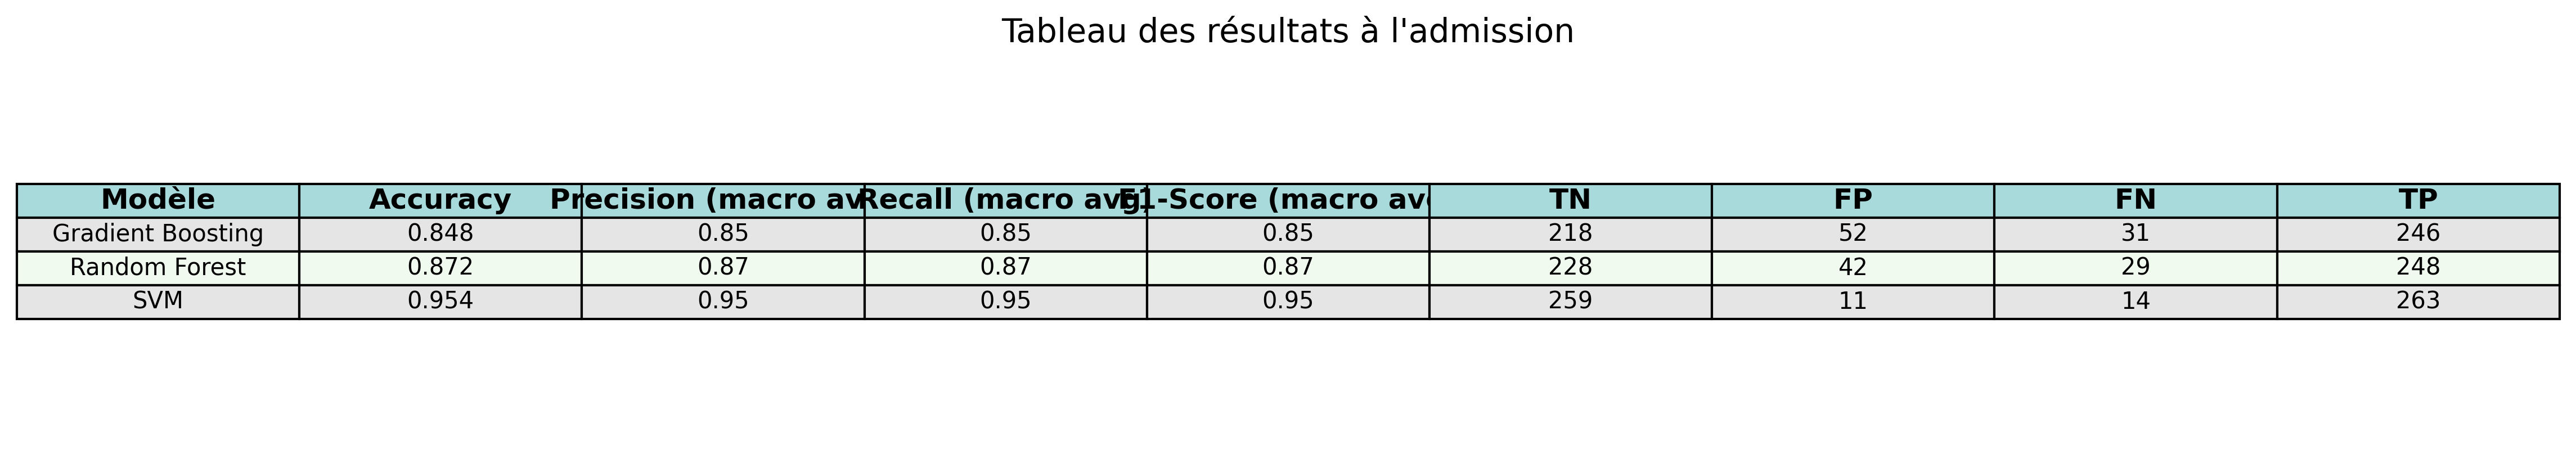

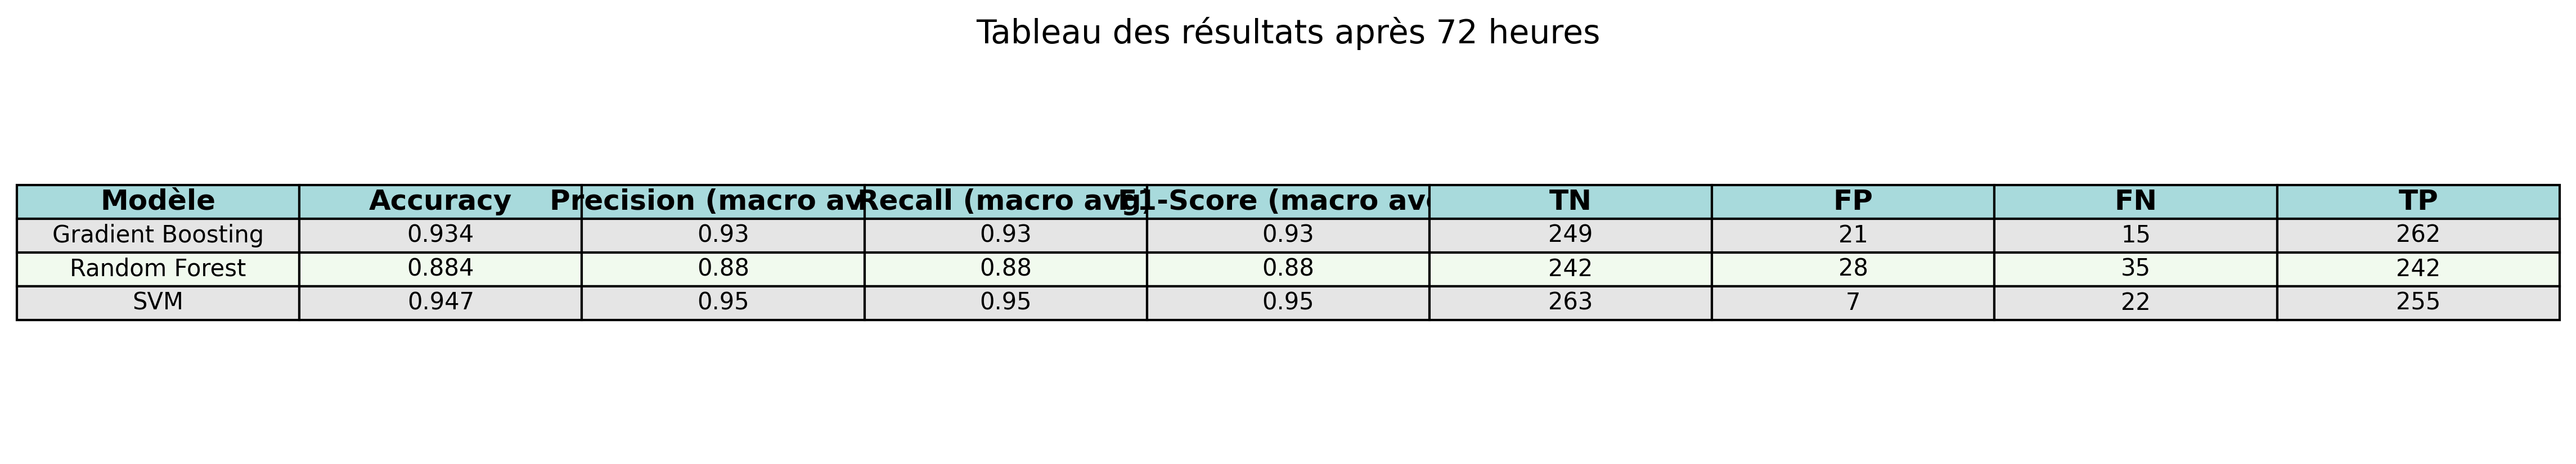

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Vérifier que le répertoire existe
output_dir = "output_images"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Données
data_admission = {
    "Modèle": ["Gradient Boosting", "Random Forest", "SVM"],
    "Accuracy": [0.848, 0.872, 0.954],
    "Precision (macro avg)": [0.85, 0.87, 0.95],
    "Recall (macro avg)": [0.85, 0.87, 0.95],
    "F1-Score (macro avg)": [0.85, 0.87, 0.95],
    "TN": [218, 228, 259],
    "FP": [52, 42, 11],
    "FN": [31, 29, 14],
    "TP": [246, 248, 263]
}

data_72h = {
    "Modèle": ["Gradient Boosting", "Random Forest", "SVM"],
    "Accuracy": [0.934, 0.884, 0.947],
    "Precision (macro avg)": [0.93, 0.88, 0.95],
    "Recall (macro avg)": [0.93, 0.88, 0.95],
    "F1-Score (macro avg)": [0.93, 0.88, 0.95],
    "TN": [249, 242, 263],
    "FP": [21, 28, 7],
    "FN": [15, 35, 22],
    "TP": [262, 242, 255]
}

# Créer des DataFrames
df_admission = pd.DataFrame(data_admission)
df_72h = pd.DataFrame(data_72h)

# Fonction pour styliser et sauvegarder un DataFrame en image
def save_styled_table(df, title, filename):
    fig, ax = plt.subplots(figsize=(12, 3))
    ax.axis('tight')
    ax.axis('off')

    table = ax.table(cellText=df.values, colLabels=df.columns, cellLoc='center', loc='center', colColours=['#f4f4f4']*len(df.columns), colWidths=[0.15]*len(df.columns))

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 1.2)

    for (i, j), cell in table.get_celld().items():
        if i == 0:
            cell.set_fontsize(12)
            cell.set_text_props(weight='bold')
            cell.set_facecolor('#a8dadc')
        elif i > 0:
            cell.set_facecolor('#f1faee' if i % 2 == 0 else '#e5e5e5')

    plt.title(title, fontsize=14)
    plt.savefig(os.path.join(output_dir, filename), bbox_inches='tight', dpi=300)
    plt.close()

# Sauvegarder les tableaux stylisés en images
save_styled_table(df_admission, "Tableau des résultats à l'admission", "resultats_admission.png")
save_styled_table(df_72h, "Tableau des résultats après 72 heures", "resultats_72h.png")

# Afficher les images dans le notebook
from IPython.display import Image
display(Image(filename=os.path.join(output_dir, "resultats_admission.png")))
display(Image(filename=os.path.join(output_dir, "resultats_72h.png")))


In [ ]:
#!pip install lifelines

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from lifelines.plotting import plot_lifetimes
from lifelines.statistics import logrank_test


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -213.90
         time fit was run = 2024-07-28 22:53:22 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ZSN       -0.97      0.38      0.61           -2.15            0.22                0.12                1.25

           cmp to     z    p  -log2(p)
covariate                             
ZSN          0.00 -1.60 0.11      3.18
---
Concordance = 0.54
Partial AIC = 429.80
log-likelihood ratio test = 3.32 on 1 df
-log2(p) of ll-ratio test = 3.87

<Figure size 1000x600 with 0 Axes>

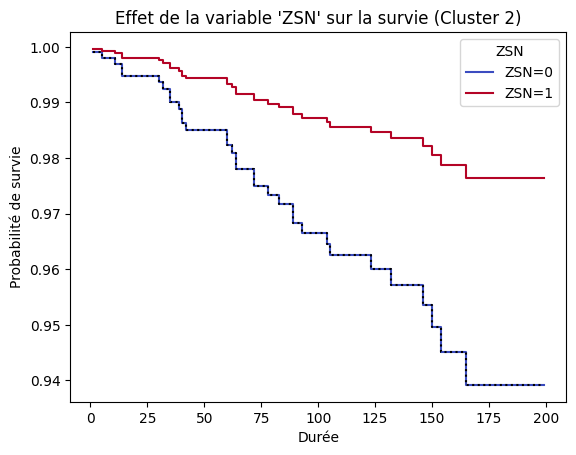

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' et 'LET_IS' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'LET_IS', 'ZSN']].copy()
df_cox.columns = ['duration', 'event', 'ZSN']
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Visualisation de l'effet de 'ZSN' sur la survie
plt.figure(figsize=(10, 6))
cox_model.plot_partial_effects_on_outcome(covariates='ZSN', values=[0, 1], cmap='coolwarm')
plt.title("Effet de la variable 'ZSN' sur la survie (Cluster 2)")
plt.xlabel("Durée")
plt.ylabel("Probabilité de survie")
plt.legend(title='ZSN', labels=['ZSN=0', 'ZSN=1'])
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -197.08
         time fit was run = 2024-07-28 21:30:55 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ZSN       -0.86      0.42      0.61           -2.05            0.33                0.13                1.39

           cmp to     z    p  -log2(p)
covariate                             
ZSN          0.00 -1.42 0.16      2.68
---
Concordance = 0.54
Partial AIC = 396.16
log-likelihood ratio test = 2.54 on 1 df
-log2(p) of ll-ratio test = 3.17

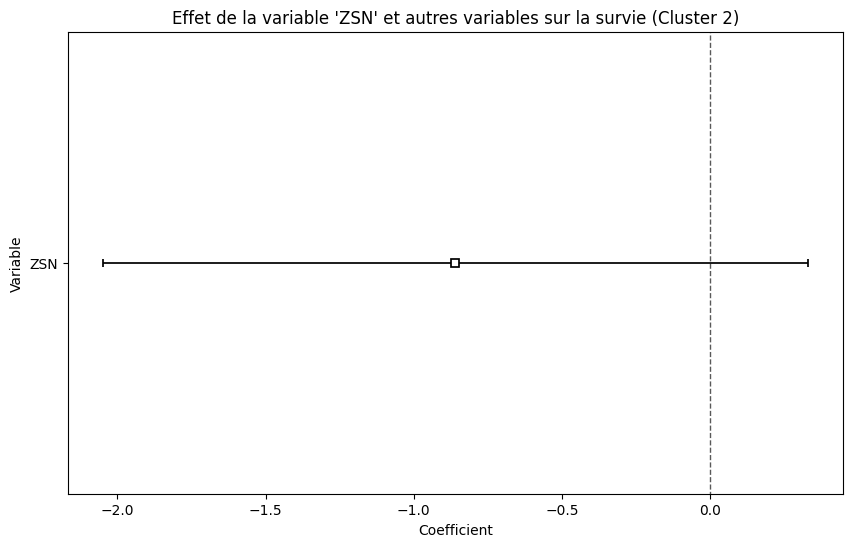

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans



# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN' et 'LET_IS' depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 1000, cluster_2_data.shape[0])

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'LET_IS', 'ZSN']].copy()
df_cox.columns = ['duration', 'event', 'ZSN']
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualisation des résultats du modèle de Cox
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Mettre en évidence les variables sélectionnées
for var in combined.index:
    if var in cox_model.params_.index:
        ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effet de la variable 'ZSN' et autres variables sur la survie (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -185.01
         time fit was run = 2024-07-28 21:41:51 UTC

---
           coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                  
ZSN       -1.19      0.30      0.61           -2.39            0.00                0.09                1.00
AGE        0.07      1.07      0.02            0.03            0.11                1.04                1.11
SEX        0.03      1.03      0.39           -0.73            0.79                0.48                2.21
INF_ANAM  -0.06      0.95      0.30           -0.64            0.53                0.53                1.70
STENOK_AN  0.09      1.09      0.16           -0.22            0.40                0.80                1.50
FK_STENOK -0.71      0.49      0.39           -1.47            0.04                0.23                1.04

           cmp to     z      p  -log2(p)
covariate                               
ZSN          0.00 -1.95   0.05      4.30
AGE          0.00  3.81 <0.005     12.84
SEX          0.00  0.08   0.94      0.09
INF_ANAM     0.00 -0.19   0.85      0.23
STENOK_AN    0.00  0.57   0.57      0.81
FK_STENOK    0.00 -1.85   0.06      3.95
---
Concordance = 0.72
Partial AIC = 382.03
log-likelihood ratio test = 26.67 on 6 df
-log2(p) of ll-ratio test = 12.55

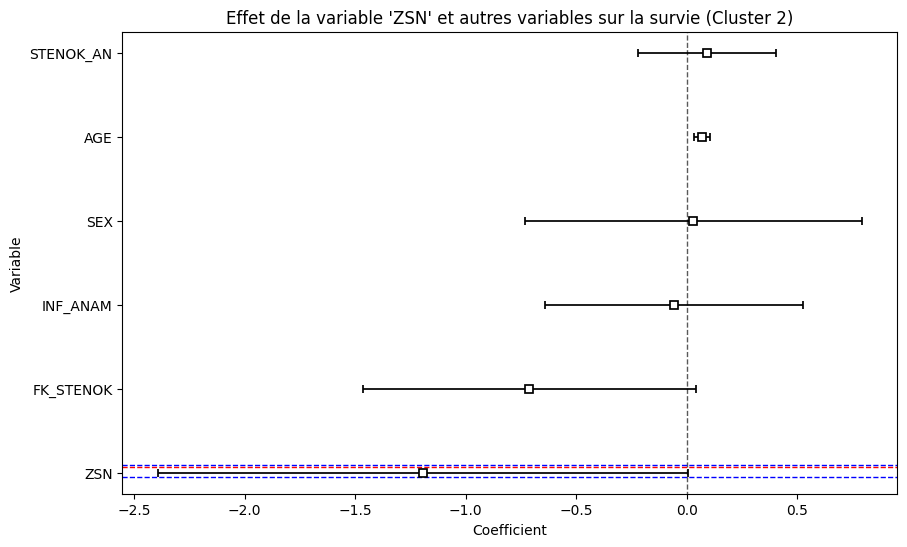

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 1000, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK']  # Ajouter plus de colonnes pertinentes
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'LET_IS', 'ZSN'] + additional_columns].copy()
df_cox.columns = ['duration', 'event', 'ZSN'] + additional_columns
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualisation des résultats du modèle de Cox
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Mettre en évidence les variables sélectionnées
for var in combined.index:
    ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effet de la variable 'ZSN' et autres variables sur la survie (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -182.07
         time fit was run = 2024-07-28 22:10:19 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.25      0.29      0.62           -2.46           -0.04                0.09                0.96
AGE         0.07      1.08      0.02            0.04            0.11                1.04                1.12
SEX         0.08      1.08      0.40           -0.71            0.87                0.49                2.39
INF_ANAM   -0.09      0.92      0.31           -0.69            0.52                0.50                1.68
STENOK_AN   0.10      1.11      0.16           -0.21            0.42                0.81                1.52
FK_STENOK  -0.72      0.49      0.39           -1.48            0.05                0.23                1.05
IBS_POST   -0.04      0.96      0.21           -0.45            0.37                0.64                1.44
GB          0.05      1.05      0.23           -0.40            0.50                0.67                1.65
SIM_GIPERT  1.67      5.29      0.69            0.31            3.02                1.37               20.46
DLIT_AG    -0.03      0.97      0.08           -0.19            0.13                0.83                1.13

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.03   0.04      4.55
AGE           0.00  3.93 <0.005     13.54
SEX           0.00  0.20   0.84      0.25
INF_ANAM      0.00 -0.29   0.78      0.37
STENOK_AN     0.00  0.65   0.52      0.95
FK_STENOK     0.00 -1.83   0.07      3.91
IBS_POST      0.00 -0.20   0.84      0.25
GB            0.00  0.22   0.83      0.27
SIM_GIPERT    0.00  2.41   0.02      5.98
DLIT_AG       0.00 -0.39   0.69      0.53
---
Concordance = 0.72
Partial AIC = 384.13
log-likelihood ratio test = 32.57 on 10 df
-log2(p) of ll-ratio test = 11.60

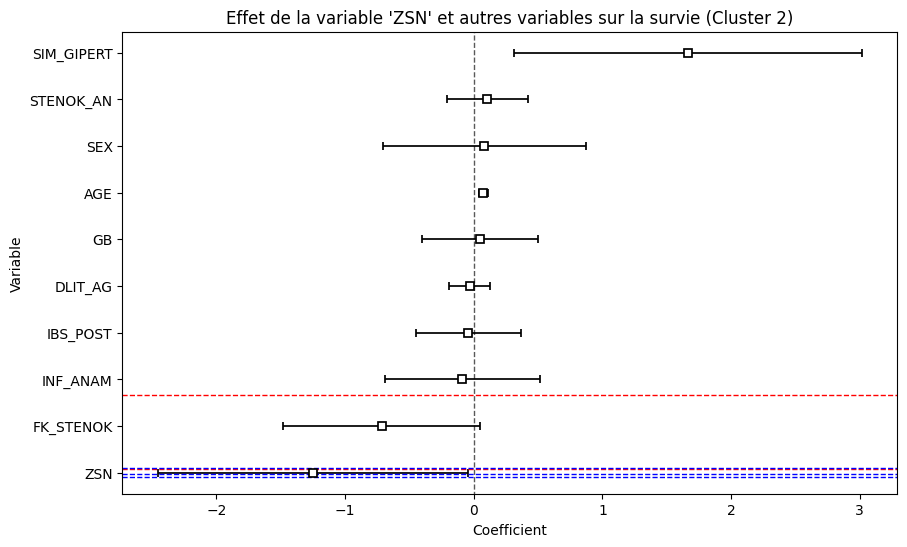

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 1000, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'LET_IS', 'ZSN'] + additional_columns].copy()
df_cox.columns = ['duration', 'event', 'ZSN'] + additional_columns
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualisation des résultats du modèle de Cox
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Mettre en évidence les variables sélectionnées
for var in combined.index:
    if var in cox_model.params_.index:
        ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effet de la variable 'ZSN' et autres variables sur la survie (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -193.15
         time fit was run = 2024-07-28 22:29:22 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.39      0.25      0.62           -2.61           -0.17                0.07                0.84
AGE         0.06      1.07      0.02            0.03            0.10                1.03                1.11
SEX        -0.23      0.80      0.40           -1.00            0.55                0.37                1.73
INF_ANAM   -0.13      0.88      0.30           -0.72            0.46                0.49                1.59
STENOK_AN   0.06      1.07      0.16           -0.25            0.37                0.78                1.45
FK_STENOK  -0.66      0.52      0.39           -1.41            0.10                0.24                1.10
IBS_POST    0.04      1.04      0.21           -0.36            0.45                0.70                1.56
GB         -0.01      0.99      0.23           -0.46            0.45                0.63                1.56
SIM_GIPERT  1.38      3.97      0.68            0.04            2.72                1.04               15.15
DLIT_AG    -0.03      0.97      0.08           -0.18            0.12                0.84                1.13

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.24   0.03      5.32
AGE           0.00  3.49 <0.005     10.99
SEX           0.00 -0.57   0.57      0.82
INF_ANAM      0.00 -0.43   0.67      0.58
STENOK_AN     0.00  0.41   0.69      0.55
FK_STENOK     0.00 -1.70   0.09      3.50
IBS_POST      0.00  0.21   0.83      0.27
GB            0.00 -0.03   0.98      0.03
SIM_GIPERT    0.00  2.02   0.04      4.52
DLIT_AG       0.00 -0.36   0.72      0.48
---
Concordance = 0.73
Partial AIC = 406.30
log-likelihood ratio test = 30.53 on 10 df
-log2(p) of ll-ratio test = 10.48

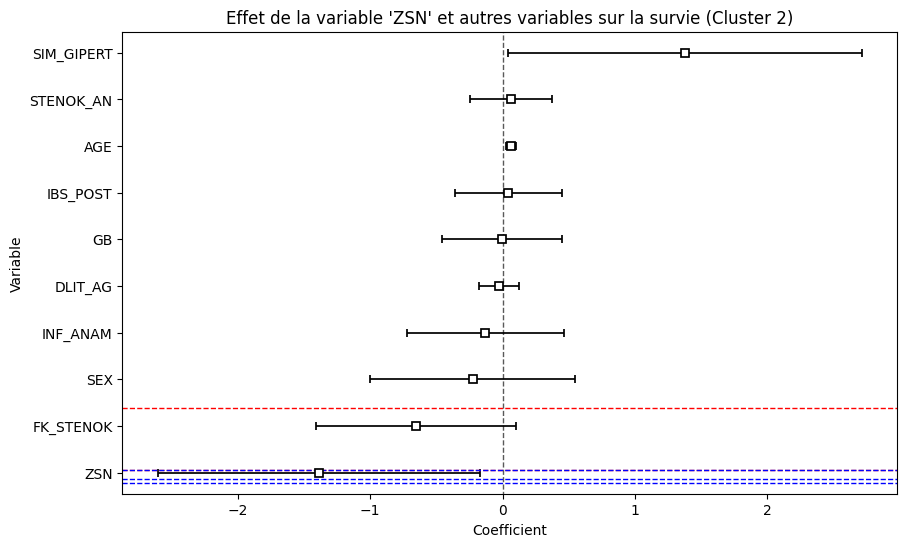

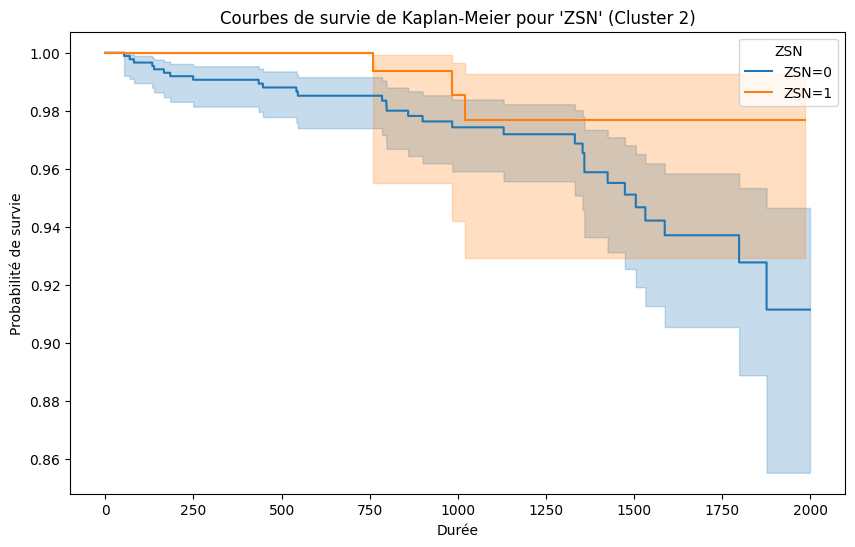

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 2000, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualisation des résultats du modèle de Cox
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Mettre en évidence les variables sélectionnées
for var in combined.index:
    if var in cox_model.params_.index:
        ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effet de la variable 'ZSN' et autres variables sur la survie (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0')
kmf.plot_survival_function(ax=ax)

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1')
kmf.plot_survival_function(ax=ax)

plt.title("Courbes de survie de Kaplan-Meier pour 'ZSN' (Cluster 2)")
plt.xlabel("Durée")
plt.ylabel("Probabilité de survie")
plt.legend(title='ZSN')
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -198.34
         time fit was run = 2024-08-01 21:44:45 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.35      0.26      0.62           -2.56           -0.14                0.08                0.87
AGE         0.07      1.07      0.02            0.03            0.10                1.03                1.11
SEX        -0.18      0.84      0.39           -0.94            0.58                0.39                1.79
INF_ANAM   -0.14      0.87      0.30           -0.73            0.46                0.48                1.58
STENOK_AN   0.13      1.14      0.16           -0.18            0.44                0.84                1.55
FK_STENOK  -0.84      0.43      0.38           -1.59           -0.09                0.20                0.91
IBS_POST   -0.03      0.97      0.21           -0.43            0.37                0.65                1.45
GB         -0.05      0.95      0.23           -0.50            0.40                0.61                1.49
SIM_GIPERT  1.66      5.25      0.65            0.38            2.94                1.46               18.90
DLIT_AG     0.00      1.00      0.08           -0.15            0.15                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.19   0.03      5.14
AGE           0.00  3.65 <0.005     11.87
SEX           0.00 -0.46   0.64      0.64
INF_ANAM      0.00 -0.45   0.65      0.62
STENOK_AN     0.00  0.84   0.40      1.31
FK_STENOK     0.00 -2.20   0.03      5.17
IBS_POST      0.00 -0.15   0.88      0.18
GB            0.00 -0.23   0.82      0.29
SIM_GIPERT    0.00  2.54   0.01      6.49
DLIT_AG       0.00  0.03   0.97      0.04
---
Concordance = 0.74
Partial AIC = 416.69
log-likelihood ratio test = 34.43 on 10 df
-log2(p) of ll-ratio test = 12.65

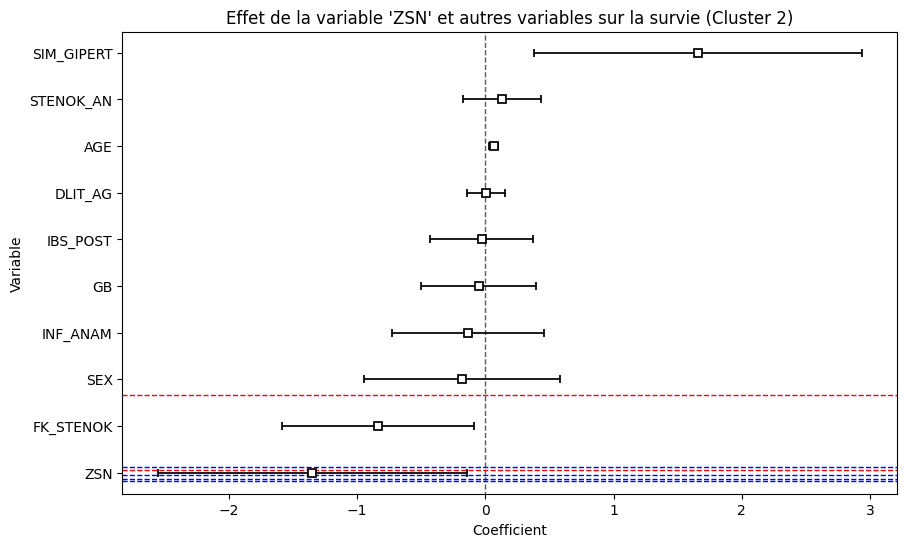

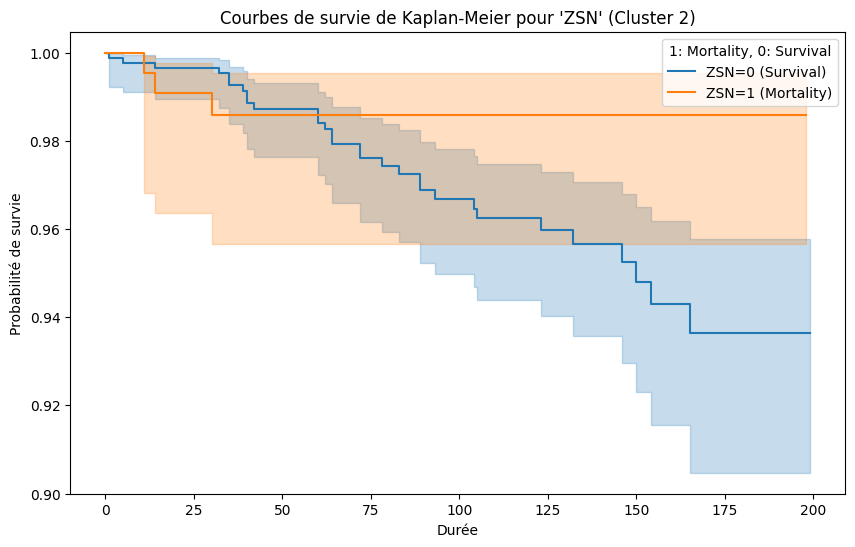

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualisation des résultats du modèle de Cox
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Mettre en évidence les variables sélectionnées
for var in combined.index:
    if var in cox_model.params_.index:
        ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effet de la variable 'ZSN' et autres variables sur la survie (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=ax)

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=ax)

plt.title("Courbes de survie de Kaplan-Meier pour 'ZSN' (Cluster 2)")
plt.xlabel("Durée")
plt.ylabel("Probabilité de survie")
plt.legend(title='1: Mortality, 0: Survival')
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -198.34
         time fit was run = 2024-08-01 21:47:32 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.35      0.26      0.62           -2.56           -0.14                0.08                0.87
AGE         0.07      1.07      0.02            0.03            0.10                1.03                1.11
SEX        -0.18      0.84      0.39           -0.94            0.58                0.39                1.79
INF_ANAM   -0.14      0.87      0.30           -0.73            0.46                0.48                1.58
STENOK_AN   0.13      1.14      0.16           -0.18            0.44                0.84                1.55
FK_STENOK  -0.84      0.43      0.38           -1.59           -0.09                0.20                0.91
IBS_POST   -0.03      0.97      0.21           -0.43            0.37                0.65                1.45
GB         -0.05      0.95      0.23           -0.50            0.40                0.61                1.49
SIM_GIPERT  1.66      5.25      0.65            0.38            2.94                1.46               18.90
DLIT_AG     0.00      1.00      0.08           -0.15            0.15                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.19   0.03      5.14
AGE           0.00  3.65 <0.005     11.87
SEX           0.00 -0.46   0.64      0.64
INF_ANAM      0.00 -0.45   0.65      0.62
STENOK_AN     0.00  0.84   0.40      1.31
FK_STENOK     0.00 -2.20   0.03      5.17
IBS_POST      0.00 -0.15   0.88      0.18
GB            0.00 -0.23   0.82      0.29
SIM_GIPERT    0.00  2.54   0.01      6.49
DLIT_AG       0.00  0.03   0.97      0.04
---
Concordance = 0.74
Partial AIC = 416.69
log-likelihood ratio test = 34.43 on 10 df
-log2(p) of ll-ratio test = 12.65

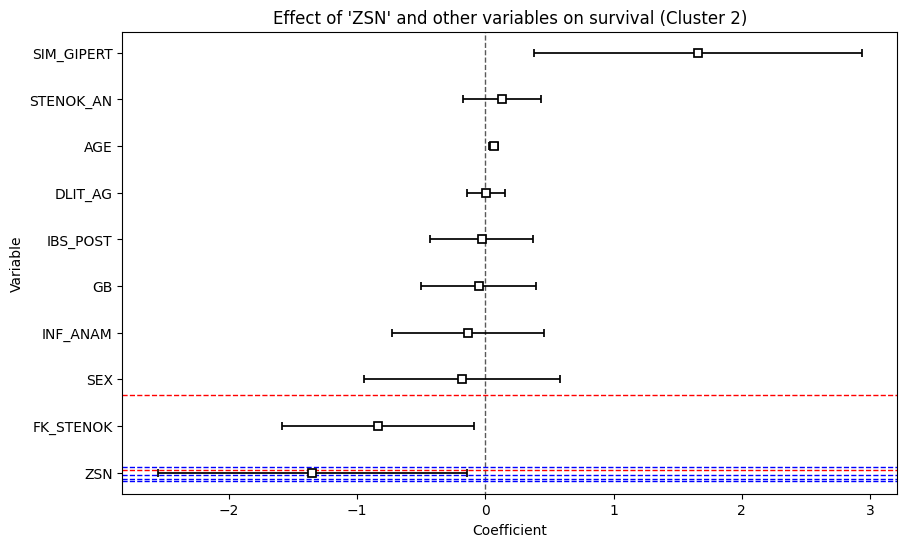

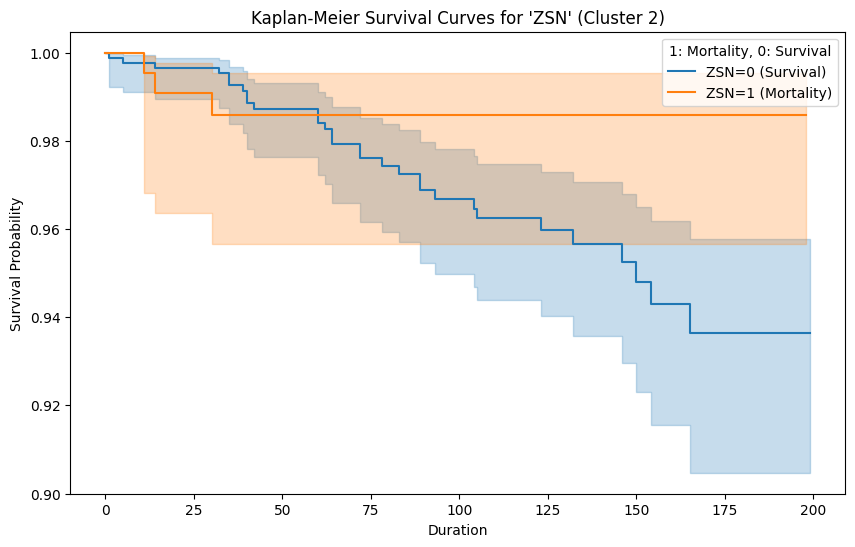

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Load data


# Data preprocessing
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Apply K-means with 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Add clusters to the initial DataFrame for analysis
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filter data for cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Re-include 'ZSN', 'LET_IS' and other variables from the initial data
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Rename 'LET_IS' column to 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Create a dummy 'duration' column (number of days since admission) for the example
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Add more variables for modeling
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclude IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Prepare data for Cox regression
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Remove missing values

# Fit Cox regression model
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Get coefficients and p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Select the top eight significant and the top four non-significant variables
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combine results for visualization
combined = pd.concat([top_8_significant, top_4_non_significant])

# Visualize Cox model results
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)

# Highlight selected variables
for var in combined.index:
    if var in cox_model.params_.index:
        ax.axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)

plt.title("Effect of 'ZSN' and other variables on survival (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
plt.show()

# Visualize the effect of 'ZSN' on survival
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

# For ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=ax)

# For ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
plt.xlabel("Duration")
plt.ylabel("Survival Probability")
plt.legend(title='1: Mortality, 0: Survival')
plt.show()


In [ ]:
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
import numpy as np
import pandas as pd

# Assuming 'data' is already loaded and preprocessed

# Data preprocessing (simplified here for illustration)
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Apply K-means with 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Add clusters to the initial DataFrame for analysis
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filter data for cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Re-include 'ZSN', 'LET_IS' and other variables from the initial data
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Rename 'LET_IS' column to 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Create a dummy 'duration' column (number of days since admission) for the example
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Add more variables for modeling
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Prepare data for Cox regression
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Remove missing values

# Fit Cox regression model
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')

# Visualize Cox model results
fig, ax = plt.subplots(figsize=(10, 6))
cox_model.plot(ax=ax)
plt.title("Effect of 'ZSN' and other variables on survival (Cluster 2)")
plt.xlabel("Coefficient")
plt.ylabel("Variable")
cox_model_plot_path = "/kaggle/working//cox_model_plot.png"
plt.savefig(cox_model_plot_path)
plt.close()

# Visualize the effect of 'ZSN' on survival
kmf = KaplanMeierFitter()

fig, ax = plt.subplots(figsize=(10, 6))

# For ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=ax)

# For ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=ax)

plt.title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
plt.xlabel("Duration")
plt.ylabel("Survival Probability")
plt.legend(title='1: Mortality, 0: Survival')
km_plot_path = "/kaggle/working/km_plot.png"
plt.savefig(km_plot_path)
plt.close()

cox_model_plot_path, km_plot_path


('/kaggle/working//cox_model_plot.png', '/kaggle/working/km_plot.png')

<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -198.34
         time fit was run = 2024-07-28 22:51:31 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.35      0.26      0.62           -2.56           -0.14                0.08                0.87
AGE         0.07      1.07      0.02            0.03            0.10                1.03                1.11
SEX        -0.18      0.84      0.39           -0.94            0.58                0.39                1.79
INF_ANAM   -0.14      0.87      0.30           -0.73            0.46                0.48                1.58
STENOK_AN   0.13      1.14      0.16           -0.18            0.44                0.84                1.55
FK_STENOK  -0.84      0.43      0.38           -1.59           -0.09                0.20                0.91
IBS_POST   -0.03      0.97      0.21           -0.43            0.37                0.65                1.45
GB         -0.05      0.95      0.23           -0.50            0.40                0.61                1.49
SIM_GIPERT  1.66      5.25      0.65            0.38            2.94                1.46               18.90
DLIT_AG     0.00      1.00      0.08           -0.15            0.15                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.19   0.03      5.14
AGE           0.00  3.65 <0.005     11.87
SEX           0.00 -0.46   0.64      0.64
INF_ANAM      0.00 -0.45   0.65      0.62
STENOK_AN     0.00  0.84   0.40      1.31
FK_STENOK     0.00 -2.20   0.03      5.17
IBS_POST      0.00 -0.15   0.88      0.18
GB            0.00 -0.23   0.82      0.29
SIM_GIPERT    0.00  2.54   0.01      6.49
DLIT_AG       0.00  0.03   0.97      0.04
---
Concordance = 0.74
Partial AIC = 416.69
log-likelihood ratio test = 34.43 on 10 df
-log2(p) of ll-ratio test = 12.65

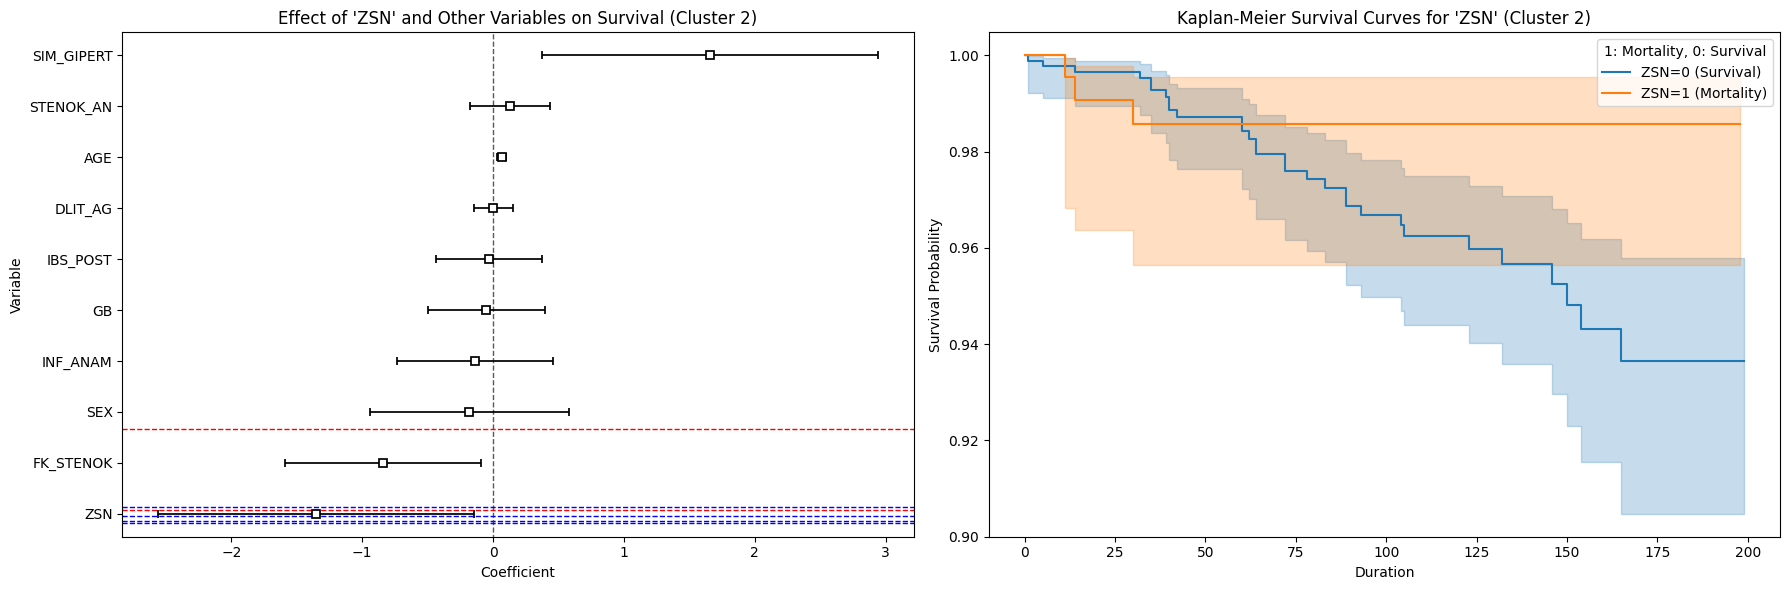

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Créer des graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisation des résultats du modèle de Cox
cox_model.plot(ax=axes[0])
for var in combined.index:
    if var in cox_model.params_.index:
        axes[0].axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)
axes[0].set_title("Effect of 'ZSN' and Other Variables on Survival (Cluster 2)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Variable")

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=axes[1])

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=axes[1])

axes[1].set_title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Survival Probability")
axes[1].legend(title='1: Mortality, 0: Survival')

plt.tight_layout()
plt.savefig('cox_kaplan_meier_plots.png')  # Sauvegarder l'image au format PNG
plt.show()


# Vendredi

<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -197.35
         time fit was run = 2024-08-16 10:12:41 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.16      0.31      0.61           -2.37            0.04                0.09                1.04
AGE         0.06      1.06      0.02            0.03            0.09                1.03                1.10
SEX        -0.14      0.87      0.39           -0.90            0.63                0.41                1.88
INF_ANAM   -0.11      0.89      0.31           -0.72            0.49                0.49                1.63
STENOK_AN   0.12      1.13      0.16           -0.19            0.42                0.83                1.53
FK_STENOK  -0.80      0.45      0.38           -1.54           -0.05                0.21                0.95
IBS_POST   -0.06      0.94      0.20           -0.46            0.34                0.63                1.40
GB         -0.01      0.99      0.23           -0.47            0.44                0.63                1.55
SIM_GIPERT  1.57      4.82      0.67            0.26            2.88                1.30               17.86
DLIT_AG    -0.01      0.99      0.08           -0.16            0.13                0.85                1.14

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -1.90   0.06      4.11
AGE           0.00  3.45 <0.005     10.82
SEX           0.00 -0.35   0.73      0.46
INF_ANAM      0.00 -0.37   0.71      0.49
STENOK_AN     0.00  0.76   0.44      1.17
FK_STENOK     0.00 -2.10   0.04      4.81
IBS_POST      0.00 -0.30   0.77      0.38
GB            0.00 -0.06   0.95      0.07
SIM_GIPERT    0.00  2.35   0.02      5.74
DLIT_AG       0.00 -0.20   0.84      0.24
---
Concordance = 0.72
Partial AIC = 414.71
log-likelihood ratio test = 30.60 on 10 df
-log2(p) of ll-ratio test = 10.52

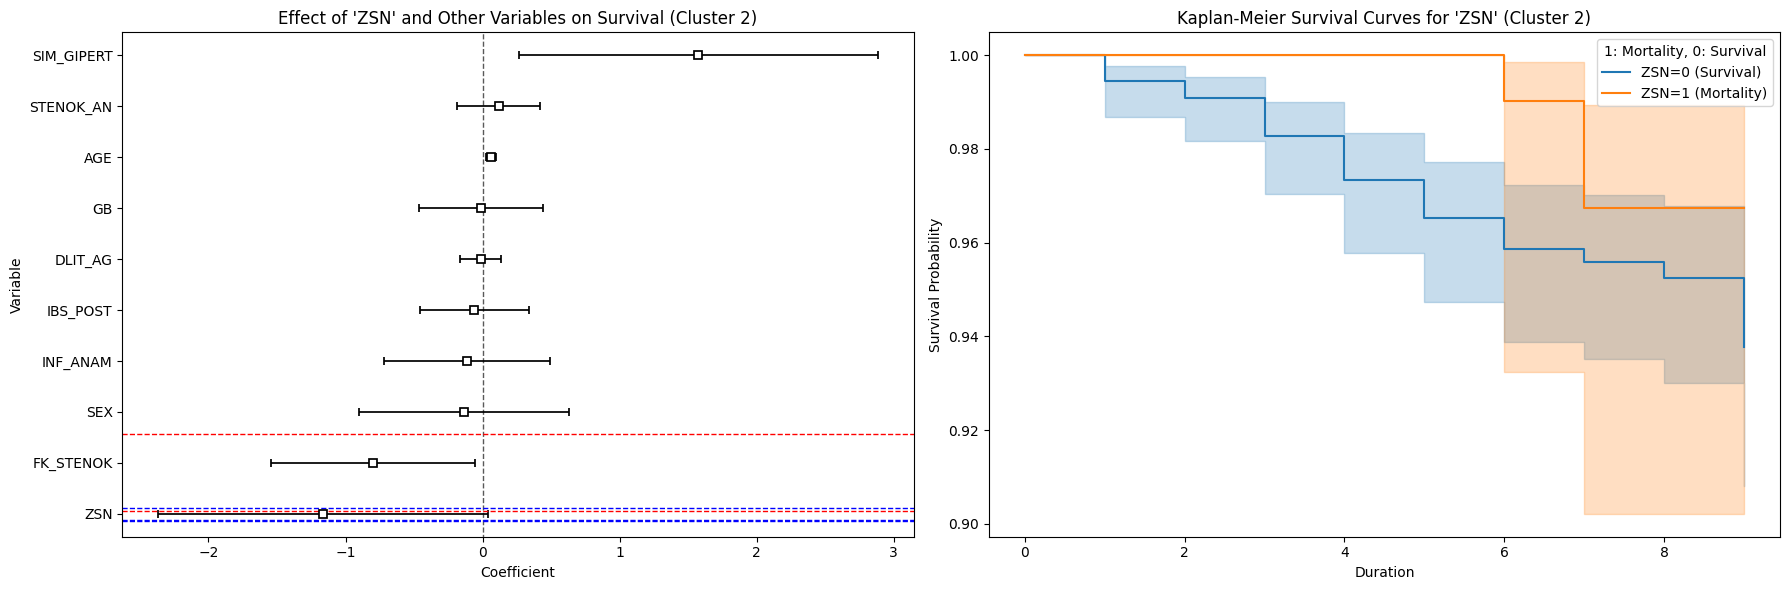

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données
# (Je suppose que la dataset est déjà chargée sous la variable 'data')

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Créer la colonne de durée basée sur les colonnes identifiées
# Par exemple, utiliser TIME_B_S comme colonne de durée
cluster_2_data['duration'] = data.loc[cluster_2_data.index, 'TIME_B_S']

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Créer des graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisation des résultats du modèle de Cox
cox_model.plot(ax=axes[0])
for var in combined.index:
    if var in cox_model.params_.index:
        axes[0].axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)
axes[0].set_title("Effect of 'ZSN' and Other Variables on Survival (Cluster 2)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Variable")

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=axes[1])

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=axes[1])

axes[1].set_title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Survival Probability")
axes[1].legend(title='1: Mortality, 0: Survival')

plt.tight_layout()
plt.savefig('cox_kaplan_meier_plots.png')  # Sauvegarder l'image au format PNG
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -211.59
         time fit was run = 2024-08-16 11:06:58 UTC

---
                 coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                        
ZSN             -1.27      0.28      0.61           -2.47           -0.06                0.08                0.94
event_na_r_diff -0.32      0.72      0.30           -0.92            0.27                0.40                1.31
AGE              0.06      1.06      0.02            0.03            0.10                1.03                1.10
SEX             -0.17      0.85      0.40           -0.94            0.61                0.39                1.84
INF_ANAM        -0.13      0.88      0.30           -0.73            0.47                0.48                1.59
STENOK_AN        0.14      1.15      0.16           -0.17            0.45                0.85                1.57
FK_STENOK       -0.80      0.45      0.39           -1.56           -0.04                0.21                0.96
IBS_POST         0.04      1.04      0.21           -0.36            0.45                0.69                1.57
GB              -0.02      0.98      0.23           -0.47            0.44                0.62                1.55
SIM_GIPERT       1.49      4.45      0.67            0.18            2.80                1.20               16.49
DLIT_AG         -0.02      0.98      0.08           -0.17            0.14                0.84                1.15

                 cmp to     z      p  -log2(p)
covariate                                     
ZSN                0.00 -2.06   0.04      4.68
event_na_r_diff    0.00 -1.06   0.29      1.80
AGE                0.00  3.40 <0.005     10.56
SEX                0.00 -0.42   0.67      0.57
INF_ANAM           0.00 -0.43   0.67      0.58
STENOK_AN          0.00  0.90   0.37      1.44
FK_STENOK          0.00 -2.05   0.04      4.65
IBS_POST           0.00  0.21   0.83      0.26
GB                 0.00 -0.08   0.94      0.09
SIM_GIPERT         0.00  2.24   0.03      5.30
DLIT_AG            0.00 -0.23   0.81      0.30
---
Concordance = 0.75
Partial AIC = 445.17
log-likelihood ratio test = 30.71 on 11 df
-log2(p) of ll-ratio test = 9.67

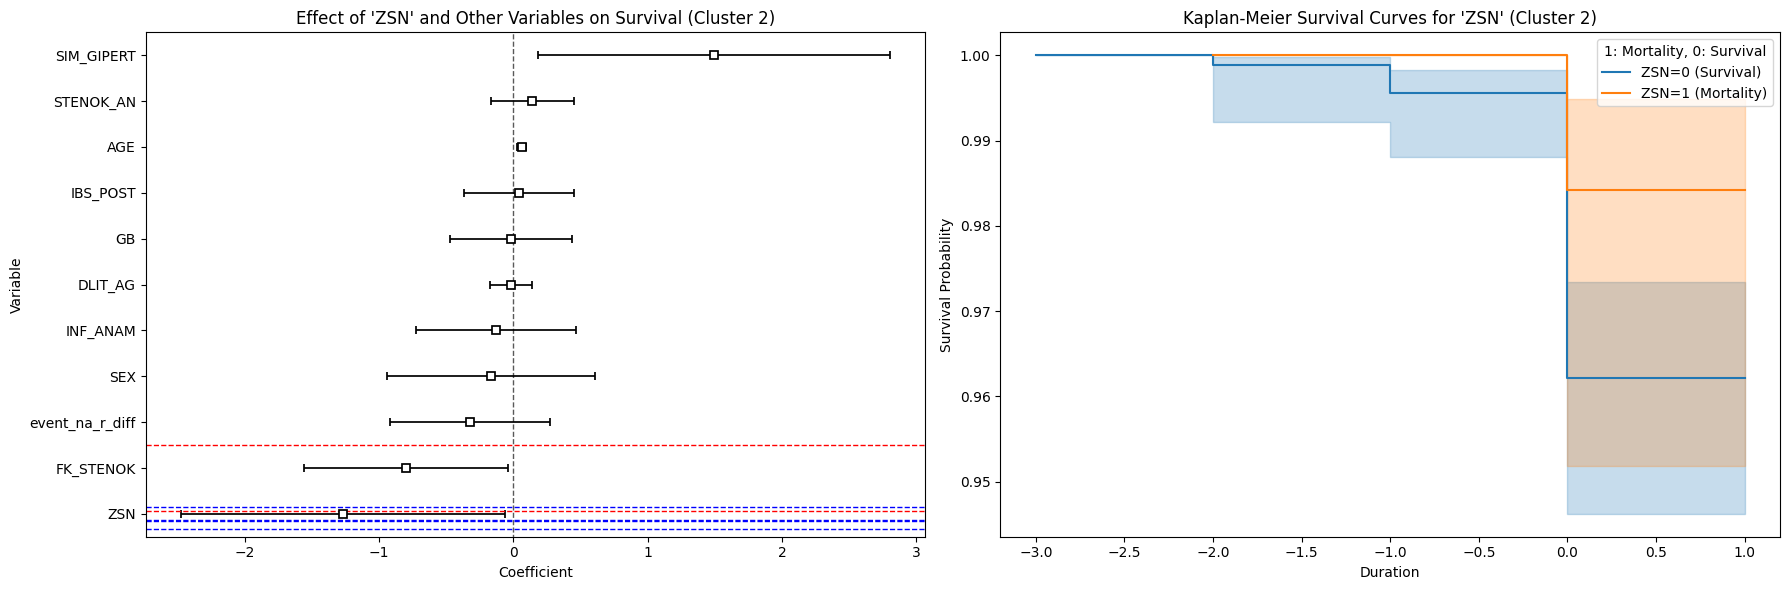

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données
# (Je suppose que la dataset est déjà chargée sous la variable 'data')

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Utiliser les colonnes `R_AB_1_n`, `R_AB_2_n`, `R_AB_3_n`, `NA_R_1_n`, `NA_R_2_n`, `NA_R_3_n`
# pour créer des nouvelles variables (par exemple, des différences entre les colonnes)

# Créer la colonne de durée basée sur la différence entre les événements
cluster_2_data['duration'] = data.loc[cluster_2_data.index, 'R_AB_3_n'] - data.loc[cluster_2_data.index, 'R_AB_1_n']

# Ajouter d'autres colonnes calculées
cluster_2_data['event_na_r_diff'] = data.loc[cluster_2_data.index, 'NA_R_3_n'] - data.loc[cluster_2_data.index, 'NA_R_1_n']

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN', 'event_na_r_diff'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Créer des graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisation des résultats du modèle de Cox
cox_model.plot(ax=axes[0])
for var in combined.index:
    if var in cox_model.params_.index:
        axes[0].axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)
axes[0].set_title("Effect of 'ZSN' and Other Variables on Survival (Cluster 2)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Variable")

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=axes[1])

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=axes[1])

axes[1].set_title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Survival Probability")
axes[1].legend(title='1: Mortality, 0: Survival')

plt.tight_layout()
plt.savefig('cox_kaplan_meier_plots.png')  # Sauvegarder l'image au format PNG
plt.show()


<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -197.61
         time fit was run = 2024-08-16 12:34:40 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.25      0.29      0.61           -2.45           -0.04                0.09                0.96
AGE         0.06      1.07      0.02            0.03            0.10                1.03                1.10
SEX        -0.08      0.92      0.39           -0.85            0.69                0.43                1.98
INF_ANAM   -0.07      0.93      0.31           -0.69            0.54                0.50                1.72
STENOK_AN   0.14      1.15      0.16           -0.17            0.45                0.84                1.57
FK_STENOK  -0.83      0.44      0.40           -1.61           -0.05                0.20                0.95
IBS_POST    0.04      1.04      0.20           -0.36            0.44                0.70                1.56
GB         -0.05      0.96      0.23           -0.49            0.40                0.61                1.49
SIM_GIPERT  1.52      4.55      0.65            0.24            2.79                1.27               16.28
DLIT_AG    -0.00      1.00      0.08           -0.15            0.14                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.03   0.04      4.56
AGE           0.00  3.53 <0.005     11.22
SEX           0.00 -0.21   0.83      0.27
INF_ANAM      0.00 -0.24   0.81      0.30
STENOK_AN     0.00  0.87   0.39      1.38
FK_STENOK     0.00 -2.10   0.04      4.80
IBS_POST      0.00  0.19   0.85      0.24
GB            0.00 -0.20   0.84      0.25
SIM_GIPERT    0.00  2.33   0.02      5.66
DLIT_AG       0.00 -0.06   0.95      0.07
---
Concordance = 0.76
Partial AIC = 415.23
log-likelihood ratio test = 30.03 on 10 df
-log2(p) of ll-ratio test = 10.20

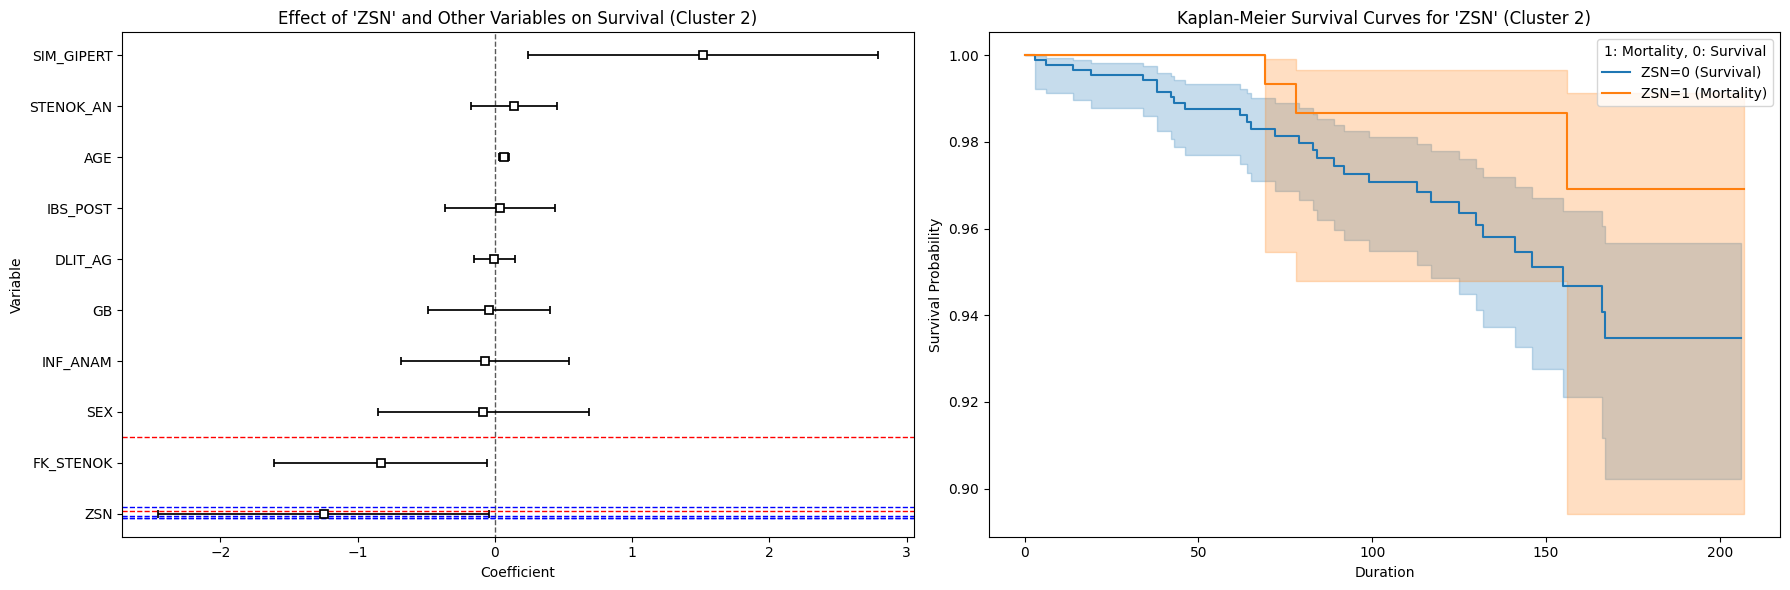

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données
# (Je suppose que la dataset est déjà chargée sous la variable 'data')

# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Augmenter la colonne de durée en ajoutant une valeur fixe ou aléatoire
# Par exemple, augmenter de 50 unités ou ajouter un nombre aléatoire
np.random.seed(42)  # Fixer la graine pour la reproductibilité

# Option 1 : Augmenter la durée par une valeur fixe
#cluster_2_data['duration'] = data.loc[cluster_2_data.index, 'TIME_B_S'] + 200

# Option 2 : Augmenter la durée en ajoutant une valeur aléatoire
cluster_2_data['duration'] = data.loc[cluster_2_data.index, 'TIME_B_S'] + np.random.randint(0, 200, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Créer des graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisation des résultats du modèle de Cox
cox_model.plot(ax=axes[0])
for var in combined.index:
    if var in cox_model.params_.index:
        axes[0].axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)
axes[0].set_title("Effect of 'ZSN' and Other Variables on Survival (Cluster 2)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Variable")

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=axes[1])

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=axes[1])

axes[1].set_title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Survival Probability")
axes[1].legend(title='1: Mortality, 0: Survival')

plt.tight_layout()
plt.savefig('cox_kaplan_meier_plots.png')  # Sauvegarder l'image au format PNG
plt.show()


In [ ]:
cox_model.print_summary()

<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -197.61
         time fit was run = 2024-08-16 12:31:38 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.25      0.29      0.61           -2.45           -0.04                0.09                0.96
AGE         0.06      1.07      0.02            0.03            0.10                1.03                1.10
SEX        -0.08      0.92      0.39           -0.85            0.69                0.43                1.98
INF_ANAM   -0.07      0.93      0.31           -0.69            0.54                0.50                1.72
STENOK_AN   0.14      1.15      0.16           -0.17            0.45                0.84                1.57
FK_STENOK  -0.83      0.44      0.40           -1.61           -0.05                0.20                0.95
IBS_POST    0.04      1.04      0.20           -0.36            0.44                0.70                1.56
GB         -0.05      0.96      0.23           -0.49            0.40                0.61                1.49
SIM_GIPERT  1.52      4.55      0.65            0.24            2.79                1.27               16.28
DLIT_AG    -0.00      1.00      0.08           -0.15            0.14                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.03   0.04      4.56
AGE           0.00  3.53 <0.005     11.22
SEX           0.00 -0.21   0.83      0.27
INF_ANAM      0.00 -0.24   0.81      0.30
STENOK_AN     0.00  0.87   0.39      1.38
FK_STENOK     0.00 -2.10   0.04      4.80
IBS_POST      0.00  0.19   0.85      0.24
GB            0.00 -0.20   0.84      0.25
SIM_GIPERT    0.00  2.33   0.02      5.66
DLIT_AG       0.00 -0.06   0.95      0.07
---
Concordance = 0.76
Partial AIC = 415.23
log-likelihood ratio test = 30.03 on 10 df
-log2(p) of ll-ratio test = 10.20

<lifelines.CoxPHFitter: fitted with 1142 total observations, 1109 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1142
number of events observed = 33
   partial log-likelihood = -198.34
         time fit was run = 2024-08-16 16:31:15 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
ZSN        -1.35      0.26      0.62           -2.56           -0.14                0.08                0.87
AGE         0.07      1.07      0.02            0.03            0.10                1.03                1.11
SEX        -0.18      0.84      0.39           -0.94            0.58                0.39                1.79
INF_ANAM   -0.14      0.87      0.30           -0.73            0.46                0.48                1.58
STENOK_AN   0.13      1.14      0.16           -0.18            0.44                0.84                1.55
FK_STENOK  -0.84      0.43      0.38           -1.59           -0.09                0.20                0.91
IBS_POST   -0.03      0.97      0.21           -0.43            0.37                0.65                1.45
GB         -0.05      0.95      0.23           -0.50            0.40                0.61                1.49
SIM_GIPERT  1.66      5.25      0.65            0.38            2.94                1.46               18.90
DLIT_AG     0.00      1.00      0.08           -0.15            0.15                0.86                1.16

            cmp to     z      p  -log2(p)
covariate                                
ZSN           0.00 -2.19   0.03      5.14
AGE           0.00  3.65 <0.005     11.87
SEX           0.00 -0.46   0.64      0.64
INF_ANAM      0.00 -0.45   0.65      0.62
STENOK_AN     0.00  0.84   0.40      1.31
FK_STENOK     0.00 -2.20   0.03      5.17
IBS_POST      0.00 -0.15   0.88      0.18
GB            0.00 -0.23   0.82      0.29
SIM_GIPERT    0.00  2.54   0.01      6.49
DLIT_AG       0.00  0.03   0.97      0.04
---
Concordance = 0.74
Partial AIC = 416.69
log-likelihood ratio test = 34.43 on 10 df
-log2(p) of ll-ratio test = 12.65

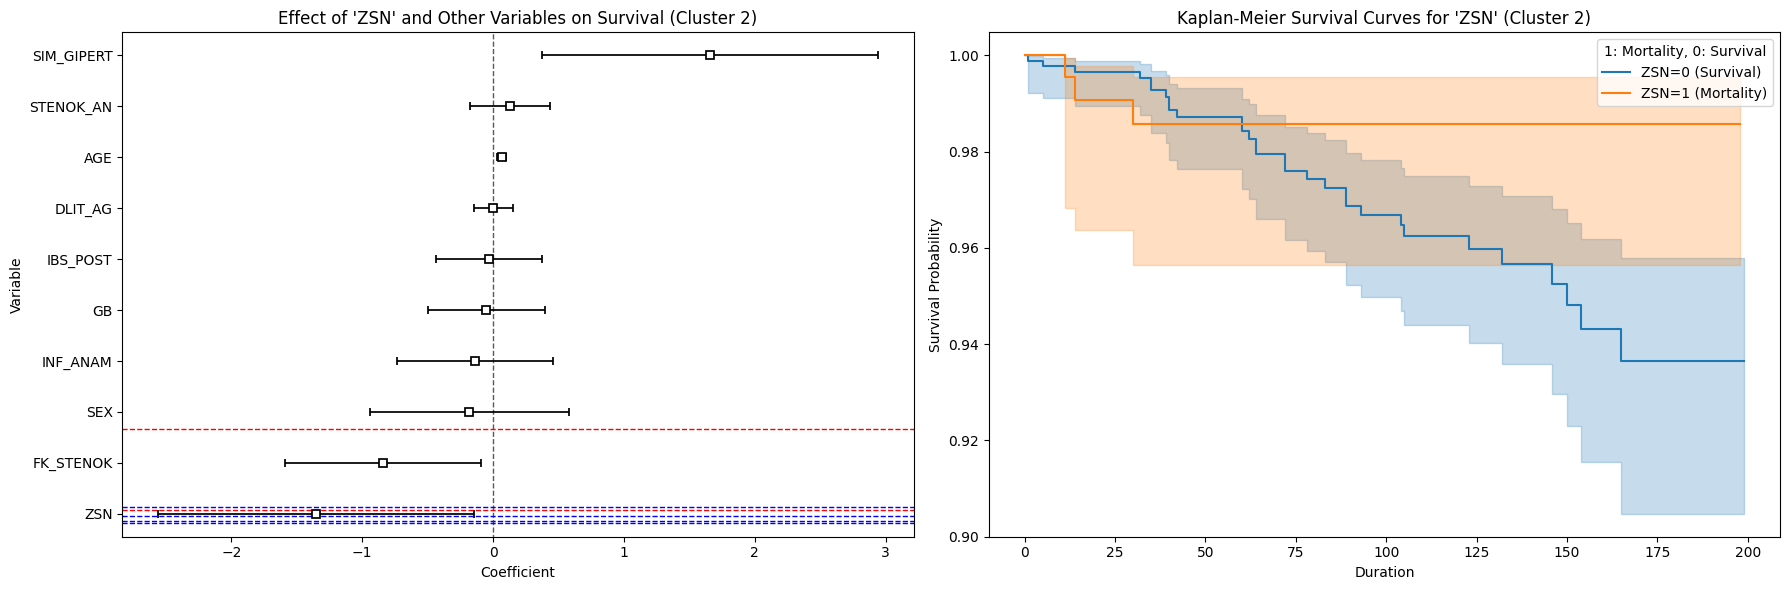

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter, KaplanMeierFitter
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Charger les données


# Prétraitement des données
input_columns = data.columns[1:112]
imputer = SimpleImputer(strategy='mean')
data_imputed = imputer.fit_transform(data[input_columns])
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_imputed)
data_preprocessed = pd.DataFrame(data_scaled, columns=input_columns)

# Appliquer K-means avec 4 clusters
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
clusters = kmeans.fit_predict(data_preprocessed)

# Ajouter les clusters au DataFrame initial pour analyse
data_with_clusters = data_preprocessed.copy()
data_with_clusters['Cluster'] = clusters

# Filtrer les données pour le cluster 2
cluster_2_data = data_with_clusters[data_with_clusters['Cluster'] == 2].copy()

# Réinclure 'ZSN', 'LET_IS' et autres variables depuis les données initiales
cluster_2_data['ZSN'] = data.loc[cluster_2_data.index, 'ZSN']
cluster_2_data['LET_IS'] = data.loc[cluster_2_data.index, 'LET_IS']

# Renommer la colonne 'LET_IS' en 'event'
cluster_2_data = cluster_2_data.rename(columns={'LET_IS': 'event'})

# Créer une colonne fictive de durée (nombre de jours depuis l'admission) pour l'exemple
np.random.seed(42)
cluster_2_data['duration'] = np.random.randint(1, 200, cluster_2_data.shape[0])

# Ajouter plus de variables pour la modélisation
additional_columns = ['AGE', 'SEX', 'INF_ANAM', 'STENOK_AN', 'FK_STENOK', 'IBS_POST', 'GB', 'SIM_GIPERT', 'DLIT_AG']  # Exclure IBS_NASL
for col in additional_columns:
    cluster_2_data[col] = data.loc[cluster_2_data.index, col]

# Préparer les données pour la régression de Cox
df_cox = cluster_2_data[['duration', 'event', 'ZSN'] + additional_columns].copy()
df_cox.dropna(inplace=True)  # Supprimer les valeurs manquantes

# Ajuster le modèle de régression de Cox
cox_model = CoxPHFitter()
cox_model.fit(df_cox, duration_col='duration', event_col='event')
cox_model.print_summary()

# Récupérer les coefficients et p-values
summary = cox_model.summary
summary_sorted = summary.sort_values(by='p', ascending=True)

# Sélectionner les huit premiers significatifs et les quatre premiers non significatifs
top_8_significant = summary_sorted[summary_sorted['p'] < 0.05].head(8)
top_4_non_significant = summary_sorted[summary_sorted['p'] >= 0.05].head(4)

# Combiner les résultats pour la visualisation
combined = pd.concat([top_8_significant, top_4_non_significant])

# Créer des graphiques côte à côte
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Visualisation des résultats du modèle de Cox
cox_model.plot(ax=axes[0])
for var in combined.index:
    if var in cox_model.params_.index:
        axes[0].axhline(y=cox_model.params_[var], color='r' if summary_sorted.loc[var, 'p'] < 0.05 else 'b', linestyle='--', linewidth=1)
axes[0].set_title("Effect of 'ZSN' and Other Variables on Survival (Cluster 2)")
axes[0].set_xlabel("Coefficient")
axes[0].set_ylabel("Variable")

# Visualisation de l'effet de 'ZSN' sur la survie
kmf = KaplanMeierFitter()

# Pour ZSN=0
mask_0 = cluster_2_data['ZSN'] == 0
kmf.fit(cluster_2_data[mask_0]['duration'], event_observed=cluster_2_data[mask_0]['event'], label='ZSN=0 (Survival)')
kmf.plot_survival_function(ax=axes[1])

# Pour ZSN=1
mask_1 = cluster_2_data['ZSN'] == 1
kmf.fit(cluster_2_data[mask_1]['duration'], event_observed=cluster_2_data[mask_1]['event'], label='ZSN=1 (Mortality)')
kmf.plot_survival_function(ax=axes[1])

axes[1].set_title("Kaplan-Meier Survival Curves for 'ZSN' (Cluster 2)")
axes[1].set_xlabel("Duration")
axes[1].set_ylabel("Survival Probability")
axes[1].legend(title='1: Mortality, 0: Survival')

plt.tight_layout()
plt.savefig('cox_kaplan_meier_plots.png')  # Sauvegarder l'image au format PNG
plt.show()
